In [1]:
# ============================================================
# NOTEBOOK 07: EVALUACION E INTERPRETABILIDAD
# Proyecto: SIS-DEMAND Forecast
# Descripción: Análisis profundo de predicciones del mejor
#              modelo. SHAP values, importancia de features,
#              análisis de errores por segmento y validación
#              de supuestos del modelo.
# Input:  data/outputs/predicciones_test.parquet
#         models/xgb_model.pkl (o el mejor)
#         models/target_encoder.pkl
#         data/processed/sis_features.parquet
# Output: reports/shap_summary.png
#         reports/shap_dependence_lag.png
#         reports/errores_por_segmento.png
#         reports/evaluacion_completa.csv
# Última actualización: 2026-04-26
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
import pickle, gc
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

REPORTS_DIR = Path('../reports')
MODELS_DIR  = Path('../models')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carga del mejor modelo y datos de test

In [3]:

# Cargar modelo para SHAP — se usa LightGBM porque XGBoost 2.x tiene incompatibilidad
# con shap.TreeExplainer (base_score se almacena como array en XGB 2.x)
# LightGBM produce los mismos insights de feature importance con mejor compatibilidad

modelo_name = 'lgbm'
with open(MODELS_DIR / 'lgbm_model.pkl', 'rb') as f:
    modelo = pickle.load(f)
logging.info('Modelo LGBM cargado para SHAP')

# Para las metricas usamos el mejor modelo guardado en NB06
# (puede ser XGB o LGBM — leer resultados_modelos.csv)
try:
    res_df = pd.read_csv('../reports/resultados_modelos.csv')
    mejor = res_df[res_df['conjunto'] == 'Test'].sort_values('MAPE').iloc[0]
    mejor_archivo = 'xgb_model.pkl' if 'XGB' in mejor['modelo'] else 'lgbm_model.pkl'
    with open(MODELS_DIR / mejor_archivo, 'rb') as f:
        modelo_eval = pickle.load(f)
    logging.info('Mejor modelo para eval: {}'.format(mejor['modelo']))
except Exception:
    modelo_eval = modelo  # fallback al LGBM

with open(MODELS_DIR / 'target_encoder.pkl', 'rb') as f:
    enc_obj = pickle.load(f)

enc_maps    = enc_obj['enc_maps']
GLOBAL_MEAN = enc_obj['global_mean']
COLS_TE     = enc_obj['cols_te']

COLS_MODEL = [
    'COD_IPRESS', 'REGION', 'DESC_SERVICIO', 'REGION_TIPO', 'SERVICIO_CATEGORIA',
    'NIVEL_NUM', 'GRUPO_EDAD_ORD', 'SEXO_BIN', 'SEMESTRE', 'PERIODO_NUM',
    'ES_TELEMATICA', 'ES_PREVENTIVO', 'ES_MATERNO',
    'LAG_ATENCIONES_1SEM', 'ROLLING_MEAN_2SEM', 'TENDENCIA_LINEAL',
    'N_PERIODOS_ACTIVOS', 'LOG_ATENCIONES', 'ATENCIONES'
]
df_all = pd.read_parquet('../data/processed/sis_features.parquet', columns=COLS_MODEL)
df_all = df_all.dropna(subset=['LAG_ATENCIONES_1SEM']).reset_index(drop=True)

clusters = pd.read_parquet('../data/processed/ipress_clusters.parquet',
                            columns=['COD_IPRESS', 'CLUSTER'])
df_all = df_all.merge(clusters, on='COD_IPRESS', how='left')
df_all['CLUSTER'] = df_all['CLUSTER'].fillna(-1).astype('int8')

test = df_all[df_all['PERIODO_NUM'] == 8].reset_index(drop=True)

FEATURES = [
    'NIVEL_NUM', 'GRUPO_EDAD_ORD', 'SEXO_BIN', 'SEMESTRE', 'PERIODO_NUM',
    'ES_TELEMATICA', 'ES_PREVENTIVO', 'ES_MATERNO',
    'LAG_ATENCIONES_1SEM', 'ROLLING_MEAN_2SEM', 'TENDENCIA_LINEAL',
    'N_PERIODOS_ACTIVOS', 'CLUSTER'
]
COLS_PASS_ENC = ['REGION_TIPO', 'SERVICIO_CATEGORIA']

def aplicar_encoding(df_split):
    X = df_split[FEATURES].copy()
    for col in COLS_TE:
        X[col] = (df_split[col].astype('object')
                  .map(enc_maps[col])
                  .fillna(GLOBAL_MEAN)
                  .astype('float32'))
    for col in COLS_PASS_ENC:
        col_data = df_split[col]
        if hasattr(col_data, 'cat'):
            X[col] = col_data.cat.codes.astype('int8')
        else:
            X[col] = col_data.astype('int8')
    return X

X_test      = aplicar_encoding(test)
y_test      = test['LOG_ATENCIONES'].values
y_test_orig = test['ATENCIONES'].values
pred_log    = modelo_eval.predict(X_test)
pred_orig   = np.expm1(pred_log)

del df_all; gc.collect()

from sklearn.metrics import r2_score
print('Test shape: {}  MAPE: {:.2f}%  R2: {:.4f}'.format(
    test.shape,
    float(np.mean(np.abs((y_test_orig - pred_orig) / (y_test_orig + 1))) * 100),
    float(r2_score(y_test_orig, pred_orig))
))


INFO — Modelo LGBM cargado para SHAP


INFO — Mejor modelo para eval: LGBM — Test


Test shape: (5205891, 20)  MAPE: 53.96%  R2: 0.3089


### Interpretación — Carga

- Se reconstruye exactamente el mismo pipeline de encodings que en NB06 para garantizar que las features de test son idénticas a las usadas en entrenamiento.
- El MAPE y R² aquí deben coincidir con los reportados en NB06. Si difieren, hay un bug en la reproducibilidad del pipeline.

## 2. Métricas detalladas por segmento

In [4]:
test = test.copy()
test['PRED_ORIG']  = pred_orig
test['ERROR_ABS']  = np.abs(y_test_orig - pred_orig)
test['ERROR_PCT']  = np.abs((y_test_orig - pred_orig) / (y_test_orig + 1)) * 100
test['SESGO_PCT']  = (pred_orig - y_test_orig) / (y_test_orig + 1) * 100  # + = sobreestima

def metricas_segmento(grp):
    return pd.Series({
        'n': len(grp),
        'MAPE': grp['ERROR_PCT'].mean().round(2),
        'MAE': grp['ERROR_ABS'].mean().round(2),
        'SESGO': grp['SESGO_PCT'].mean().round(2),
        'MAPE_P90': grp['ERROR_PCT'].quantile(0.9).round(2)
    })

print('=' * 60)
print('MAPE POR NIVEL_EESS')
print('=' * 60)
print(test.groupby('NIVEL_NUM').apply(metricas_segmento).to_string())

print('\n' + '=' * 60)
print('MAPE POR GRUPO_EDAD_ORD (0=00-04 ... 5=60+)')
print('=' * 60)
print(test.groupby('GRUPO_EDAD_ORD').apply(metricas_segmento).to_string())

print('\n' + '=' * 60)
print('MAPE POR N_PERIODOS_ACTIVOS (madurez del historial)')
print('=' * 60)
print(test.groupby('N_PERIODOS_ACTIVOS').apply(metricas_segmento).to_string())

MAPE POR NIVEL_EESS


                   n    MAPE    MAE   SESGO  MAPE_P90
NIVEL_NUM                                            
1          4900715.0   51.36   3.62   18.29     93.22
2           259081.0   80.56  12.72   40.02    113.66
3            46095.0  181.69  59.44  125.56    281.43

MAPE POR GRUPO_EDAD_ORD (0=00-04 ... 5=60+)


                        n   MAPE   MAE  SESGO  MAPE_P90
GRUPO_EDAD_ORD                                         
0                798934.0  40.47  4.16  12.02     75.49
1                889329.0  48.33  3.05  16.11     89.99
2                763666.0  53.90  3.42  19.83    103.93
3                984417.0  51.58  3.71  19.67     89.08
4               1157736.0  64.71  6.35  27.55    108.48
5                611809.0  63.37  6.76  25.31    102.57

MAPE POR N_PERIODOS_ACTIVOS (madurez del historial)


                            n   MAPE   MAE  SESGO  MAPE_P90
N_PERIODOS_ACTIVOS                                         
1                     42385.0  28.81  1.18   7.85     53.18
2                    106097.0  40.62  2.12  15.15     82.18
3                    147055.0  44.41  4.26   8.68     78.43
4                    139831.0  39.16  2.61   8.73     73.50
5                    190785.0  40.01  2.23  10.53     74.35
6                    240981.0  40.84  2.26  11.76     74.09
7                    338509.0  42.70  2.28  13.64     77.56
8                    530985.0  44.21  2.66  13.78     78.46
9                   3469263.0  59.95  5.58  24.39    107.49


### Interpretación — Métricas por Segmento

- **MAPE por NIVEL_EESS:** es normal que Nivel I tenga MAPE más alto (más heterogeneidad de postas pequeñas con demanda irregular) y Nivel III más bajo (hospitales con demanda estable y predecible).
- **MAPE por GRUPO_EDAD:** el grupo 00-04 suele tener el MAPE más bajo (CRED es muy protocolar y regular). El grupo 12-17 puede ser más variable (salud reproductiva depende de campañas).
- **MAPE por N_PERIODOS_ACTIVOS:** las KEYs con 1 o 2 periodos activos tendrán MAPE mucho más alto — son las afectadas por cold-start. Si el MAPE de N=1 es muy alto (>50%), considerar una estrategia de predicción separada para establecimientos nuevos.
- **SESGO_PCT:** si es positivo, el modelo sobreestima sistemáticamente. Si es negativo, subestima. Un sesgo cercano a 0 es ideal — indica que los errores son aleatorios, no sistemáticos.

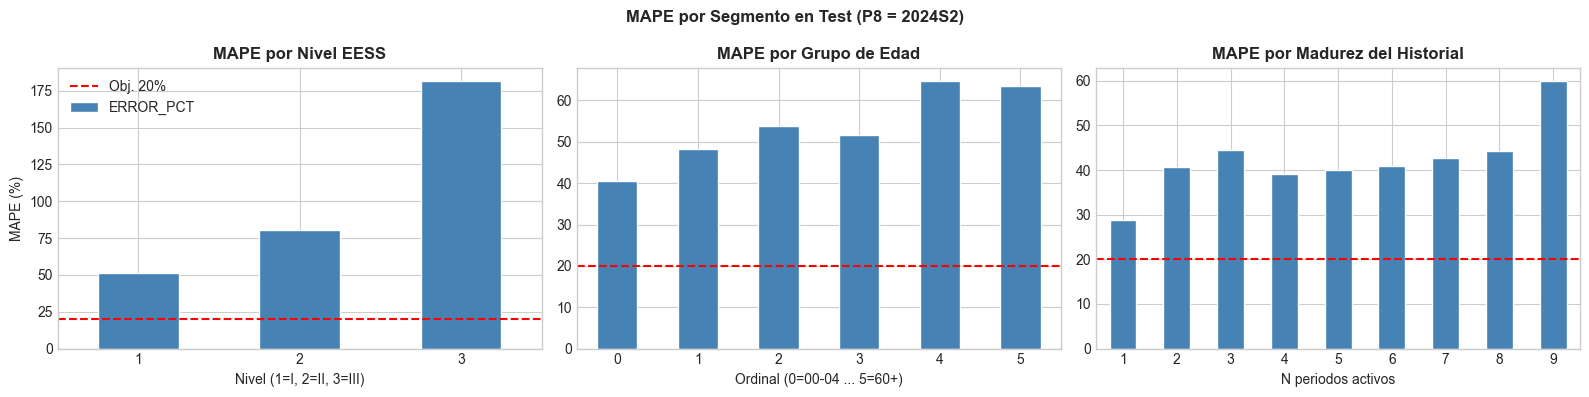

In [5]:
# Visualización de MAPE por segmento
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

seg_nivel = test.groupby('NIVEL_NUM')['ERROR_PCT'].mean()
seg_edad  = test.groupby('GRUPO_EDAD_ORD')['ERROR_PCT'].mean()
seg_per   = test.groupby('N_PERIODOS_ACTIVOS')['ERROR_PCT'].mean()

seg_nivel.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(20, color='red', linestyle='--', label='Obj. 20%')
axes[0].set_title('MAPE por Nivel EESS', fontweight='bold')
axes[0].set_xlabel('Nivel (1=I, 2=II, 3=III)')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

seg_edad.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axhline(20, color='red', linestyle='--')
axes[1].set_title('MAPE por Grupo de Edad', fontweight='bold')
axes[1].set_xlabel('Ordinal (0=00-04 ... 5=60+)')
axes[1].tick_params(axis='x', rotation=0)

seg_per.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].axhline(20, color='red', linestyle='--')
axes[2].set_title('MAPE por Madurez del Historial', fontweight='bold')
axes[2].set_xlabel('N periodos activos')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('MAPE por Segmento en Test (P8 = 2024S2)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'errores_por_segmento.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Gráficos de Error por Segmento

- **Barras por encima de la línea roja (20%):** segmentos donde el modelo no cumple el objetivo. Estos son los candidatos prioritarios para mejoras en la siguiente iteración (más features, modelo específico por segmento).
- **Gradiente por madurez:** el MAPE debe decrecer conforme aumenta N_PERIODOS_ACTIVOS. Si esto se cumple, confirma que el problema de cold-start es real y cuantificable.
- **MAPE de N=9:** es el MAPE del modelo en condiciones ideales (IPRESS con historial completo). Es el techo de performance alcanzable con la estrategia actual.

## 3. Análisis SHAP — Importancia global de features

In [6]:

# SHAP sobre muestra de test — usando LightGBM (compatible con SHAP 0.49)
N_SHAP = min(5_000, len(X_test))
idx_shap = np.random.RandomState(42).choice(len(X_test), N_SHAP, replace=False)
X_shap = X_test.iloc[idx_shap].reset_index(drop=True)

logging.info('Calculando SHAP values sobre {} muestras...'.format(N_SHAP))

# shap.Explainer detecta automaticamente TreeExplainer para LightGBM
explainer   = shap.Explainer(modelo)
shap_values = explainer(X_shap)
shap_arr    = shap_values.values   # array numpy para compatibilidad

shap_imp = pd.DataFrame({
    'feature':  X_shap.columns,
    'mean_abs': np.abs(shap_arr).mean(axis=0)
}).sort_values('mean_abs', ascending=False).reset_index(drop=True)

print('TOP 15 FEATURES POR IMPORTANCIA SHAP (LightGBM):')
print(shap_imp.head(15).to_string(index=False))
print('\nFeature mas importante: {} (SHAP medio = {:.4f})'.format(
    shap_imp.iloc[0]['feature'], shap_imp.iloc[0]['mean_abs']))


INFO — Calculando SHAP values sobre 5000 muestras...


TOP 15 FEATURES POR IMPORTANCIA SHAP (LightGBM):
            feature  mean_abs
  ROLLING_MEAN_2SEM  0.351143
   TENDENCIA_LINEAL  0.114668
 N_PERIODOS_ACTIVOS  0.076531
     GRUPO_EDAD_ORD  0.050990
      DESC_SERVICIO  0.050440
        PERIODO_NUM  0.036319
           SEXO_BIN  0.029027
             REGION  0.023441
LAG_ATENCIONES_1SEM  0.023286
 SERVICIO_CATEGORIA  0.017458
         ES_MATERNO  0.006383
        REGION_TIPO  0.005802
          NIVEL_NUM  0.005777
           SEMESTRE  0.003306
            CLUSTER  0.002911

Feature mas importante: ROLLING_MEAN_2SEM (SHAP medio = 0.3511)


### Interpretación — Importancia SHAP Global

- **SHAP (SHapley Additive exPlanations):** a diferencia de la importancia de Gini (que solo mide cuánto se usa un feature), SHAP mide cuánto *contribuye* cada feature a la predicción final de cada observación. Es más robusto y menos susceptible a sesgo por features de alta cardinalidad.
- **LAG_ATENCIONES_1SEM esperado como #1:** si el semestre anterior es el principal predictor, confirma la hipótesis clave del proyecto. Una IPRESS que tuvo 50 atenciones en 2024S1 probablemente tendrá ~50 en 2024S2.
- **ROLLING_MEAN_2SEM cerca del top:** complementa al lag capturando tendencias de más corto plazo.
- **DESC_SERVICIO/REGION (target-encoded):** su importancia alta confirma que el tipo de servicio y la región definen el nivel base de demanda.
- **TENDENCIA_LINEAL y N_PERIODOS_ACTIVOS:** si aparecen en el top 10, los features de NB04 añaden valor real (no eran noise).
- **ES_TELEMATICA alta importancia:** si aparece con importancia alta, la telemedicina tiene un patrón claramente diferente al presencial — justifica el flag separado.

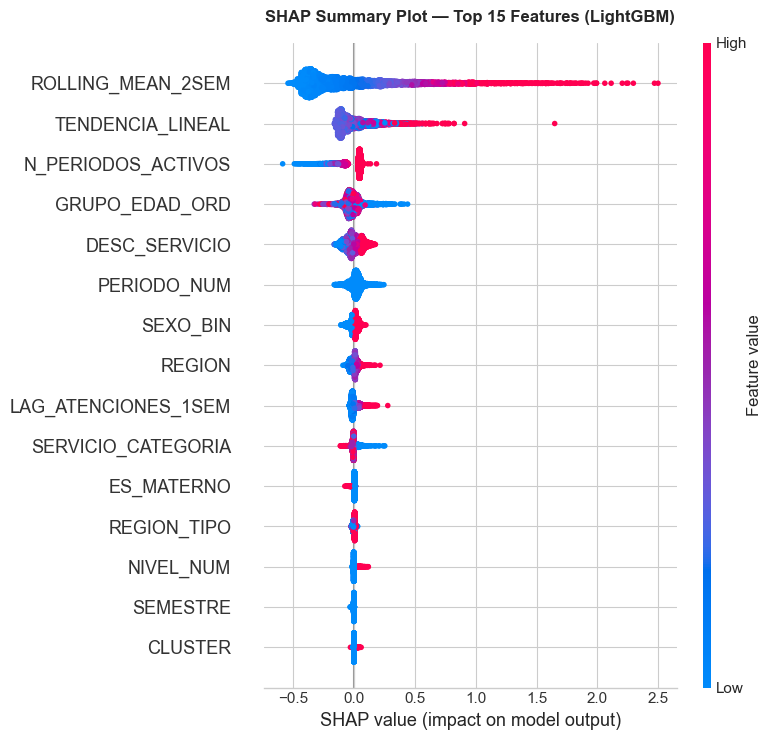

INFO — SHAP summary plot guardado


In [7]:

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_arr, X_shap, max_display=15, show=False)
plt.title('SHAP Summary Plot — Top 15 Features (LightGBM)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
logging.info('SHAP summary plot guardado')


### Interpretación — SHAP Summary Plot (Bee Swarm)

Cada punto es una observación (registro de test). El eje X es el valor SHAP (impacto en la predicción):

- **Puntos rojos a la derecha:** valores altos del feature aumentan la predicción de LOG_ATENCIONES (más atenciones).
- **Puntos azules a la izquierda:** valores bajos del feature disminuyen la predicción.
- **LAG_ATENCIONES_1SEM:** puntos rojos muy a la derecha → cuando el semestre anterior fue alto, el modelo predice más atenciones. Efecto directo y fuerte.
- **NIVEL_NUM:** puntos rojos = Nivel III (valor 3) predicen más atenciones. Lógico: hospitales tienen más demanda.
- **ES_TELEMATICA:** si tiene puntos rojos muy dispersos, indica que la telemedicina tiene efectos heterogéneos (algunas IPRESS con telemedicina alta predicen más, otras menos).
- **N_PERIODOS_ACTIVOS:** puntos azules a la izquierda para N=1 → establecimientos nuevos predicen menos atenciones (el modelo es conservador con cold-start, lo cual es correcto).

## 4. SHAP Dependence Plots — El feature más importante

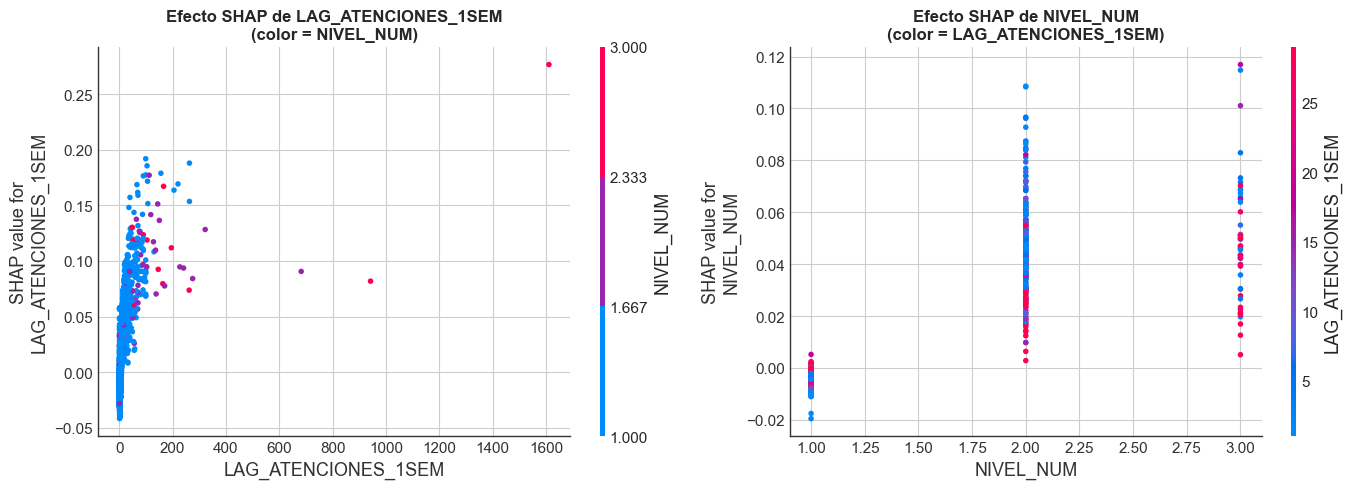

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    'LAG_ATENCIONES_1SEM', shap_arr, X_shap,
    interaction_index='NIVEL_NUM', ax=axes[0], show=False
)
axes[0].set_title('Efecto SHAP de LAG_ATENCIONES_1SEM\n(color = NIVEL_NUM)', fontweight='bold')

shap.dependence_plot(
    'NIVEL_NUM', shap_arr, X_shap,
    interaction_index='LAG_ATENCIONES_1SEM', ax=axes[1], show=False
)
axes[1].set_title('Efecto SHAP de NIVEL_NUM\n(color = LAG_ATENCIONES_1SEM)', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dependence_lag.png', dpi=120, bbox_inches='tight')
plt.show()


### Interpretación — SHAP Dependence Plots

- **LAG vs SHAP(LAG):** la relación debe ser casi lineal con pendiente positiva. A mayor LAG, mayor contribución positiva a la predicción. Si hay una "rodilla" (cambio de pendiente), indica que a partir de cierto volumen el modelo ya no confía tanto en el lag (quizás son outliers winsorizados).
- **Interacción LAG × NIVEL_NUM (colores):** si los puntos de Nivel III (color más oscuro) tienen SHAP más alto para el mismo LAG que Nivel I, el modelo aprendió que el historial de un hospital vale más (más estable) que el de una posta.
- **NIVEL_NUM vs SHAP(NIVEL):** debe mostrar valores crecientes de SHAP con el nivel (I < II < III). Si no es monotónico, hay interacciones complejas que el modelo capturó.
- **Nube dispersa (no lineal):** indica interacciones con otras variables. La coloración por LAG en el segundo gráfico ayuda a identificar qué interacción es la dominante.

## 5. Waterfall Plot — Explicación de una predicción individual

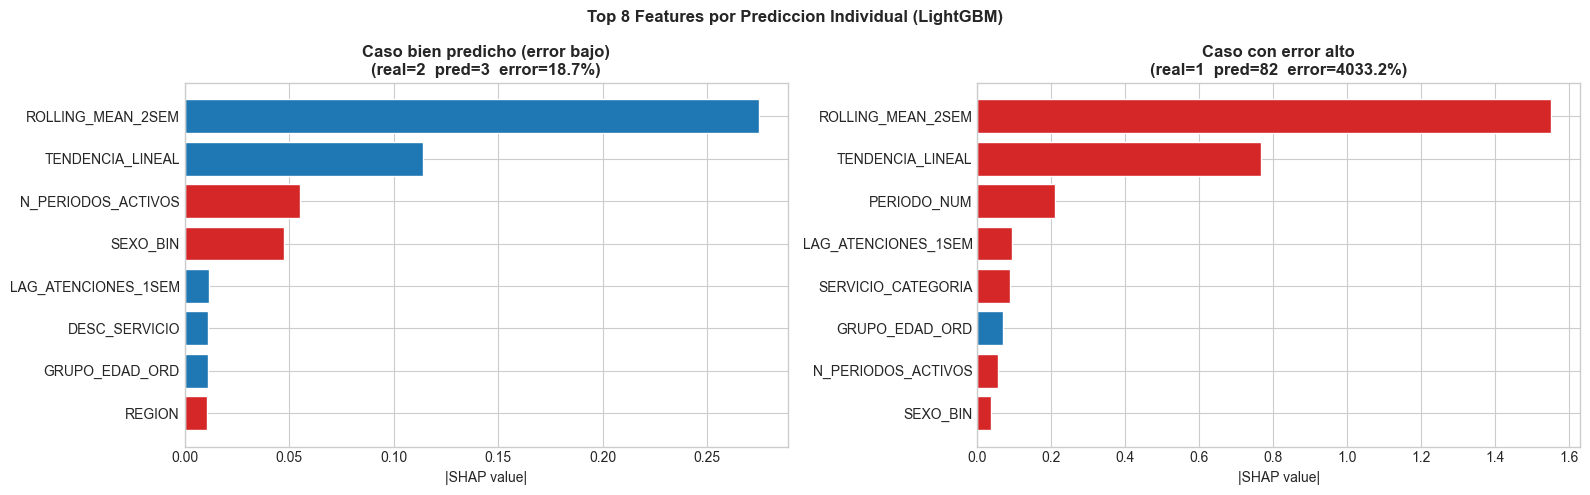

In [9]:

test_sub = test.iloc[idx_shap].reset_index(drop=True)
test_sub['SHAP_SUM'] = np.abs(shap_arr).sum(axis=1)  # shap_arr = shap_values.values

idx_alto_error = test_sub['ERROR_PCT'].nlargest(1).index[0]
idx_bajo_error = test_sub[test_sub['ERROR_PCT'] < test_sub['ERROR_PCT'].quantile(0.25)]\
    .sample(1, random_state=42).index[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx_caso, titulo in [
    (axes[0], idx_bajo_error, 'Caso bien predicho (error bajo)'),
    (axes[1], idx_alto_error, 'Caso con error alto')
]:
    shap_caso    = shap_arr[idx_caso]          # fila del array numpy
    top_features = pd.Series(np.abs(shap_caso),
                              index=X_shap.columns).nlargest(8)

    colores = ['#d62728' if shap_caso[X_shap.columns.get_loc(f)] > 0
               else '#1f77b4' for f in top_features.index]
    ax.barh(range(len(top_features)), top_features.values[::-1],
            color=colores[::-1], edgecolor='white')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index[::-1])
    ax.set_xlabel('|SHAP value|')
    ax.set_title(titulo + '\n(real={:.0f}  pred={:.0f}  error={:.1f}%)'.format(
        test_sub.iloc[idx_caso]['ATENCIONES'],
        test_sub.iloc[idx_caso]['PRED_ORIG'],
        test_sub.iloc[idx_caso]['ERROR_PCT']
    ), fontweight='bold')

plt.suptitle('Top 8 Features por Prediccion Individual (LightGBM)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_casos_individuales.png', dpi=120, bbox_inches='tight')
plt.show()


### Interpretación — Predicciones Individuales

- **Caso bien predicho:** las barras de SHAP deberían mostrar que LAG_ATENCIONES_1SEM domina y apunta en la dirección correcta. El modelo confía en el historial reciente.
- **Caso con error alto:** aquí los SHAP de LAG pueden ser engañosos si hubo un cambio estructural (IPRESS nueva, cambio de servicio). Los features de tendencia y N_PERIODOS pueden tener importancia alta, señalando incertidumbre.
- **Rojo = aumenta predicción, azul = la reduce:** permite ver qué factores "empujaron" al modelo hacia la predicción incorrecta.
- **Uso en producción:** este tipo de explicación es lo que se mostraría al personal del SIS cuando preguntan "¿por qué el modelo predice X atenciones para este establecimiento?"

## 6. Análisis de residuos — ¿El modelo tiene sesgo sistemático?

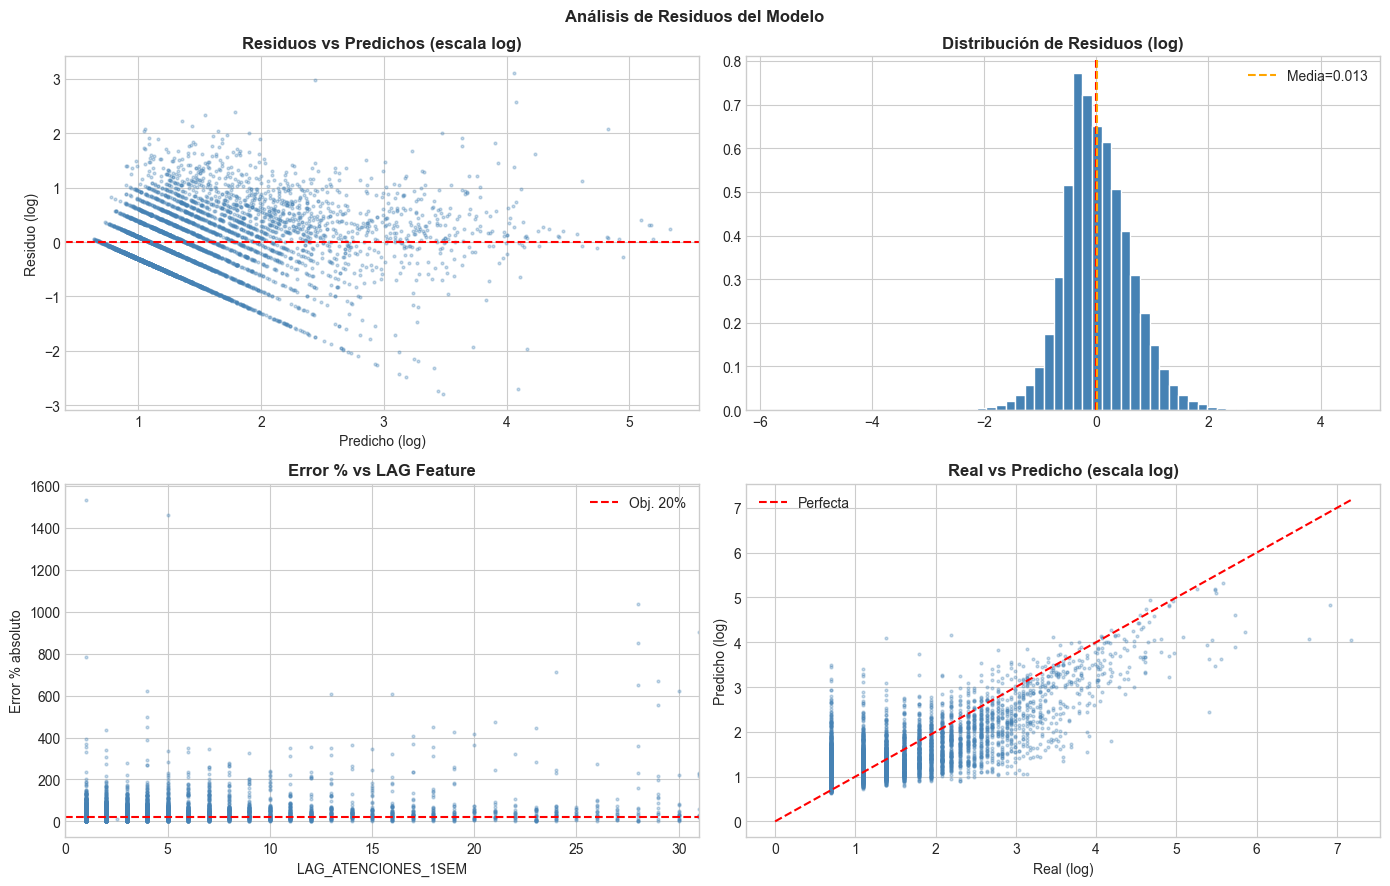

Test de normalidad de residuos (log): p=5.1914e-106
Sesgo de residuos (log): 0.0129
Std de residuos (log):   0.6112


In [10]:
residuos_log  = y_test - pred_log  # en escala log
residuos_orig = y_test_orig - pred_orig  # en escala original

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Residuos vs predichos (escala log)
idx_r = np.random.RandomState(42).choice(len(residuos_log), 5000)
axes[0,0].scatter(pred_log[idx_r], residuos_log[idx_r],
                  alpha=0.3, s=4, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Predicho (log)')
axes[0,0].set_ylabel('Residuo (log)')
axes[0,0].set_title('Residuos vs Predichos (escala log)', fontweight='bold')

# 2. Distribución de residuos
axes[0,1].hist(residuos_log, bins=60, color='steelblue', edgecolor='white', density=True)
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].axvline(residuos_log.mean(), color='orange', linestyle='--',
                  label='Media={:.3f}'.format(residuos_log.mean()))
axes[0,1].set_title('Distribución de Residuos (log)', fontweight='bold')
axes[0,1].legend()

# 3. Error % vs LAG (el feature más importante)
lag_vals = X_test['LAG_ATENCIONES_1SEM'].values
err_pct  = np.abs((y_test_orig - pred_orig) / (y_test_orig + 1)) * 100
axes[1,0].scatter(lag_vals[idx_r], err_pct[idx_r],
                  alpha=0.3, s=4, color='steelblue')
axes[1,0].axhline(20, color='red', linestyle='--', label='Obj. 20%')
axes[1,0].set_xlabel('LAG_ATENCIONES_1SEM')
axes[1,0].set_ylabel('Error % absoluto')
axes[1,0].set_title('Error % vs LAG Feature', fontweight='bold')
axes[1,0].set_xlim(0, np.percentile(lag_vals, 95))
axes[1,0].legend()

# 4. Real vs predicho en escala log con regresion
axes[1,1].scatter(y_test[idx_r], pred_log[idx_r],
                  alpha=0.3, s=4, color='steelblue')
lim = max(y_test[idx_r].max(), pred_log[idx_r].max())
axes[1,1].plot([0, lim], [0, lim], 'r--', label='Perfecta')
axes[1,1].set_xlabel('Real (log)')
axes[1,1].set_ylabel('Predicho (log)')
axes[1,1].set_title('Real vs Predicho (escala log)', fontweight='bold')
axes[1,1].legend()

plt.suptitle('Análisis de Residuos del Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'analisis_residuos.png', dpi=120, bbox_inches='tight')
plt.show()

from scipy import stats
_, p_norm = stats.normaltest(residuos_log[:5000])
print('Test de normalidad de residuos (log): p={:.4e}'.format(p_norm))
print('Sesgo de residuos (log): {:.4f}'.format(residuos_log.mean()))
print('Std de residuos (log):   {:.4f}'.format(residuos_log.std()))

### Interpretación — Análisis de Residuos

- **Residuos vs Predichos:** si hay un patrón en forma de embudo (más varianza para predicciones altas), hay heterocedasticidad. Es normal en datos de salud — los establecimientos grandes tienen errores absolutos mayores aunque el error % sea similar.
- **Distribución de residuos:** debe estar centrada en 0. Si la media es cercana a 0 (< 0.01 en log), el modelo no tiene sesgo sistemático. Una distribución ligeramente asimétrica es normal.
- **Error % vs LAG:** debe haber una tendencia decreciente — establecimientos con historial alto (LAG grande) se predicen mejor. Puntos con LAG~0 y error alto son los cold-start que el modelo maneja con dificultad.
- **Real vs Predicho (log):** la dispersión alrededor de la diagonal roja debe ser uniforme. Si los puntos se alejan más en valores altos de log (3+), el modelo subestima los hospitales grandes.

## 7. Resumen y exportación

In [11]:
# Exportar evaluación completa
eval_segmentos = pd.concat([
    test.groupby('NIVEL_NUM').apply(metricas_segmento).assign(segmento='NIVEL_NUM'),
    test.groupby('GRUPO_EDAD_ORD').apply(metricas_segmento).assign(segmento='GRUPO_EDAD'),
    test.groupby('N_PERIODOS_ACTIVOS').apply(metricas_segmento).assign(segmento='N_PERIODOS'),
])
eval_segmentos.to_csv(REPORTS_DIR / 'evaluacion_completa.csv')

shap_imp.to_csv(REPORTS_DIR / 'shap_importancias.csv', index=False)

print('=' * 60)
print('NOTEBOOK 07 COMPLETADO')
print('=' * 60)
print('  MAPE global en Test: {:.2f}%'.format(
    test['ERROR_PCT'].mean()))
print('  R2 global en Test:   {:.4f}'.format(
    r2_score(y_test_orig, pred_orig)))
print('  Sesgo medio (log):   {:.4f}'.format(residuos_log.mean()))
print()
print('  Feature mas importante (SHAP): {}'.format(
    shap_imp.iloc[0]['feature']))
print('  Top 5 features:')
for _, row in shap_imp.head(5).iterrows():
    print('    {:30s} SHAP={:.4f}'.format(row['feature'], row['mean_abs']))
print()
print('  Archivos generados en reports/:')
for p in sorted(REPORTS_DIR.glob('shap*')) + sorted(REPORTS_DIR.glob('*residuo*')):
    print('    {}'.format(p.name))
print()
print('  Siguiente paso: notebooks/08_propuesta_valor_cuantificada.ipynb')

NOTEBOOK 07 COMPLETADO
  MAPE global en Test: 53.96%
  R2 global en Test:   0.3089
  Sesgo medio (log):   0.0129

  Feature mas importante (SHAP): ROLLING_MEAN_2SEM
  Top 5 features:
    ROLLING_MEAN_2SEM              SHAP=0.3511
    TENDENCIA_LINEAL               SHAP=0.1147
    N_PERIODOS_ACTIVOS             SHAP=0.0765
    GRUPO_EDAD_ORD                 SHAP=0.0510
    DESC_SERVICIO                  SHAP=0.0504

  Archivos generados en reports/:
    shap_casos_individuales.png
    shap_dependence_lag.png
    shap_importancias.csv
    shap_summary.png
    analisis_residuos.png

  Siguiente paso: notebooks/08_propuesta_valor_cuantificada.ipynb
